In [2]:
# %% [Instalación completa]
!apt-get update
!apt-get install -y poppler-utils tesseract-ocr tesseract-ocr-spa

!pip install --upgrade pip
!pip install mistralai pykeen pdf2image pytesseract Pillow nltk networkx matplotlib transformers torch huggingface-hub  pymupdf unidecode spacy owlready2 numpy
!pip install langdetect

import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')

!python -m spacy download es_core_news_lg

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.8 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,302 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,640 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,289 kB]
Hit:11 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:13 http://archive.ubuntu.com/

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.0/568.0 MB 15.0 MB/s  0:00:23
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
!pip install faiss-cpu  # O faiss-gpu si tienes una instancia con GPU potente

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 51.0 MB/s  0:00:00


Para persistir datos en drive -not used-

In [1]:
from google.colab import drive
import pickle
import pandas as pd
import numpy as np
import os

# Montar Google Drive
drive.mount('/content/drive')

# Definir rutas en Drive
DRIVE_PATH = '/content/drive/MyDrive/Colab Datasets'
os.makedirs(DRIVE_PATH, exist_ok=True)

# Guardar cualquier objeto Python
def save_to_drive(obj, filename):
    """Guarda cualquier objeto en Google Drive"""
    filepath = os.path.join(DRIVE_PATH, filename)
    with open(filepath, 'wb') as f:
        pickle.dump(obj, f)
    print(f"✅ Guardado: {filepath}")
    return filepath

def load_from_drive(filename):
    """Carga objetos desde Google Drive"""
    filepath = os.path.join(DRIVE_PATH, filename)
    with open(filepath, 'rb') as f:
        obj = pickle.load(f)
    print(f"✅ Cargado: {filepath}")
    return obj

# Ejemplo de uso:
# Guardar
# save_to_drive(df_ontology, 'df_ontology.pkl')
# save_to_drive(ontology_embeddings, 'ontology_embeddings.pkl')
# save_to_drive(parsed_entities, 'parsed_entities.pkl')

# En una nueva sesión:
# df_ontology = load_from_drive('df_ontology.pkl')
# ontology_embeddings = load_from_drive('ontology_embeddings.pkl')

MessageError: Error: credential propagation was unsuccessful

# **Procesamiento de Texto**

In [4]:
STOPWORDS = set(
    [
        "introducción",
        "método",
        "métodos",
        "resultado",
        "resultados",
        "discusión",
        "conclusión",
        "figura",
        "tabla",
        "referencia",
        "estudio",
        "análisis",
        "datos",
        "artículo",
        "sección",
        "mostrado",
        "usando",
        "usado",
        "basado",
        "encontrado",
        "también",
        "sin embargo",
        "aunque",
        "año",
        "años",
        "tiempo",
        "alto",
        "bajo",
        "valor",
        "caso",
        "grupo",
        "et",
        "al",
        "probabilidad",
        "momento",
        "situaciones",
        "descubrir",
        "mantiene",
        "significaba",
        "quizás",
        "debido",
        "uso",
        "hacer",
        "obtener",
        "puede",
        "podría",
        "listado",
        "conferencias",
        "antecedentes",
        "significancia",
        "derechos de autor",
        "autor",
        "fig",
        "ec",
        "vol",
    ]
)

BLACKLIST = {
    "fig", "figura", "figure", "tabla", "table", "cuadro", "doi", "issn",
    "url", "http", "www", "et", "al", "vol", "no", "pág", "pag", "ed",
    "estudio", "análisis", "datos", "método", "resultado", "conclusión"
}

In [25]:
from idna import decode
import pdf2image
import fitz
import pytesseract
from unidecode import unidecode
import nltk
import hashlib
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
from pathlib import Path
import string
import spacy
import os
import re

try:
    nlp = spacy.load("es_core_news_lg")
    print("✅ Modelo spaCy 'es_core_news_lg' cargado correctamente.")
except OSError:
    print("⚠️ Error cargando spaCy. Asegúrate de haber ejecutado la celda de instalación.")


nltk.download("punkt")
nltk.download("stopwords")


ruta_local = os.path.expanduser("./model")
# Configurar la ruta de la carpeta
carpeta_txts = "/content/drive/MyDrive/txts"  # Cambiado a Google Drive
carpeta_pdfs = Path("/content/drive/MyDrive/corpus")
carpeta_pdfs = Path(carpeta_pdfs)
article_txt = ""
all_articles_text = []

# Asegurarse de que la carpeta existe
if not carpeta_pdfs.exists():
    carpeta_pdfs.mkdir(parents=True, exist_ok=True)
    print(f"Carpeta '{carpeta_pdfs}' creada. Coloca tus PDFs allí.")
else:
    article_txt = ""

    for pdf_file in carpeta_pdfs.glob("*.pdf"):
        print(f"\nProcesando: {pdf_file.name}")

        article_txt = ""  # Variable local para cada PDF

        try:
            # Construir nombre del archivo txt
            pdf_file_name = pdf_file.with_suffix(".txt").name
            file_name = Path(carpeta_txts) / pdf_file_name # FIX: Changed './txts' to 'carpeta_txts'

            print(file_name)
            if file_name.exists():
                print(f"  El archivo {file_name.name} ya existe. Cargando texto existente...")
                with open(file_name, "r", encoding="utf-8") as f:
                    article_txt = f.read()
            else:
                doc = fitz.open(pdf_file)
                full_text_pages = []

                for page in doc:
                    blocks = page.get_text("blocks", sort=True)
                    page_text_parts = []
                    for block in blocks:
                        txt = block[4]
                        if not txt.strip() or len(txt) < 5:
                            continue
                        txt = re.sub(r'([a-záéíóúñ])([A-ZÁÉÍÓÚÑ])', r'\1 \2', txt)
                        page_text_parts.append(txt)

                    full_text_pages.append("\n".join(page_text_parts))

                article_txt = "\n".join(full_text_pages)
                article_txt = re.sub(r'\s+', ' ', article_txt).strip()

                # Guardar el texto extraído
                file_name.parent.mkdir(parents=True, exist_ok=True)
                with open(file_name, "w", encoding="utf-8") as f:
                    f.write(article_txt)

                print(f"  Texto extraído y guardado en {file_name.name}")

            # Agregar a la lista de todos los textos
            if article_txt.strip():
                print(article_txt)  # Solo si no está vacío
                all_articles_text.append(article_txt)

        except Exception as e:
            print(f"  Error procesando {pdf_file.name}: {e}")

# Combinar todos los textos
combined_text = "\n\n".join(all_articles_text)
print(combined_text)

Output hidden; open in https://colab.research.google.com to view.

In [26]:
from langdetect import detect, LangDetectException

def is_spanish(text):
    try:
        # Si el texto es muy corto, langdetect falla o es impreciso
        if len(text.split()) < 4:
            return False
        return detect(text) == 'es'
    except LangDetectException:
        return False

# Mejora en la limpieza de texto para unir palabras partidas por guiones
def clean_text(text):
    text = re.split(r'\n\s*(Referencia|Bibliograf|Bibliography|References)', text, flags=re.IGNORECASE)[0]
    text = re.sub(r'(\w)-\n(\w)', r'\1\2', text)

    lines = text.split('\n')
    clean_lines = []
    for line in lines:
        if len(line.strip()) < 3 or line.strip().isdigit():
            continue
        clean_lines.append(line.strip())

    text = " ".join(clean_lines)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

ctext = clean_text(combined_text)
print(ctext)

Output hidden; open in https://colab.research.google.com to view.

# **NER**

In [27]:
from transformers import pipeline, AutoTokenizer, AutoModelForTokenClassification

model_name = "HUMADEX/spanish_medical_ner"
try:
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForTokenClassification.from_pretrained(model_name)

    ner_pipeline = pipeline(
        "ner",
        model=model,
        tokenizer=tokenizer,
        aggregation_strategy="max"
    )
except Exception as e:
    print(f"Error cargando modelo: {e}")
    raise

Device set to use cuda:0


In [28]:
entity_list = []

ENGLISH_STOPWORDS = {"the", "of", "and", "in", "to", "with", "a", "for", "study", "fistulae", "skull", "base", "flap", "nasoseptal"}
STOPWORDS.update(ENGLISH_STOPWORDS)

entity_list = []

# Tokenizar oraciones
sentences = nltk.tokenize.sent_tokenize(ctext, language="spanish")

for s in sentences:
    if not is_spanish(s):
        continue

    if len(s) < 20: continue

    results = ner_pipeline(s)
    doc = nlp(s)

    denotations = []
    seen_lemmas = set()

    for ent in results:
        if ent["score"] < 0.60: continue
        span = doc.char_span(ent["start"], ent["end"], alignment_mode="contract")

        if not span:
            lemma = ent["word"].strip().lower()
        else:
            lemma_parts = [t.lemma_.lower() for t in span]
            lemma = " ".join(lemma_parts)
            lemma = unidecode(lemma)

        # Limpieza final del lema
        lemma = re.sub(r'[^\w\s]', '', lemma).strip()

        if (len(lemma) < 4 or
            lemma in STOPWORDS or
            lemma in BLACKLIST or
            lemma.isdigit() or
            any(w in ENGLISH_STOPWORDS for w in lemma.split())):
            continue

        label = ent["entity_group"]

        if lemma not in seen_lemmas:
            denotations.append({
                "obj": label,
                "span": {"begin": ent["start"], "end": ent["end"]},
                "lemma": lemma,
                "original": ent["word"]
            })
            seen_lemmas.add(lemma)

    if denotations:
        entity_list.append({"text": s, "denotations": denotations})

In [29]:
parsed_entities = []
for entities_in_sentence in entity_list:
    e = []
    # If there are not entities in the text
    if not entities_in_sentence.get("denotations"):
        parsed_entities.append(
            {
                "text": entities_in_sentence["text"],
                "text_sha256": hashlib.sha256(
                    entities_in_sentence["text"].encode("utf-8")
                ).hexdigest(),
            }
        )
        continue

    for entity_denotation in entities_in_sentence["denotations"]:
        entity_id = entity_denotation["lemma"]
        other_ids = []
        entity_type = entity_denotation["obj"]

        processed_lemma_for_graph = entity_denotation["lemma"]

        # Apply final filtering steps to this processed_lemma
        if processed_lemma_for_graph in STOPWORDS or len(processed_lemma_for_graph) < 3 or len(processed_lemma_for_graph) > 60 or processed_lemma_for_graph.isdigit() or not re.search(r'[a-záéíóúñ]', processed_lemma_for_graph, re.I):
            continue

        e.append(
            {
                "entity_id": entity_id,
                "other_ids": other_ids,
                "entity_type": entity_type,
                "entity": processed_lemma_for_graph,
                "start": entity_denotation["span"]["begin"],
                "end": entity_denotation["span"]["end"]
            }
        )

    parsed_entities.append(
        {
            "entities": e,
            "text": entities_in_sentence["text"],
            "text_sha256": hashlib.sha256(entities_in_sentence["text"].encode("utf-8")).hexdigest(),
        }
    )


Inspeccionar contenido de parsed_entities

In [ ]:
import json

print("=" * 80)
print("CONTENIDO COMPLETO DE parsed_entities")
print("=" * 80)

# Imprimir con indentación para mejor legibilidad
print(f"Tipo: {type(parsed_entities)}")
print(f"Longitud total: {len(parsed_entities)}")

for i, doc in enumerate(parsed_entities):
    print(f"\n{'='*60}")
    print(f"DOCUMENTO {i+1}/{len(parsed_entities)}")
    print(f"{'='*60}")

    if isinstance(doc, dict):
        print("Estructura tipo DICT:")
        print(json.dumps(doc, indent=2, ensure_ascii=False, default=str))
    elif isinstance(doc, list):
        print("Estructura tipo LISTA:")
        print(json.dumps(doc, indent=2, ensure_ascii=False, default=str))
    else:
        print(f"Tipo inesperado: {type(doc)}")
        print(f"Contenido: {doc}")

Se han truncado las últimas 5000 líneas del flujo de salida.
      "entity": "introduccion",
      "start": 57,
      "end": 69
    }
  ],
  "text": "Texto ≤3000 palabras en español (≤2500 en inglés), desde Introducción hasta Agradecimientos, ambos incluidos.",
  "text_sha256": "24167718fbb320fcd93ffd96e83b3474b77b2d8b20dbab2075745ac895b48642"
}

DOCUMENTO 1004/1131
Estructura tipo DICT:
{
  "entities": [
    {
      "entity_id": "seccion",
      "other_ids": [],
      "entity_type": "TEST",
      "entity": "seccion",
      "start": 42,
      "end": 49
    },
    {
      "entity_id": "subject",
      "other_ids": [],
      "entity_type": "TEST",
      "entity": "subject",
      "start": 175,
      "end": 182
    }
  ],
  "text": "https://doi.org/10.37757/MR2021.V23.N3.10 Sección Notas Resuma los puntos, recomendaciones o argumentos claves del ensayo Proporcione 3–10 palabras claves (Ver Me SH, Medical Subject Headings).",
  "text_sha256": "9995325372b5d975e50cf2552cc74673c52fa7c3760e8d

# **Alignment**

In [ ]:
import pandas as pd
import numpy as np
import faiss
import torch
from sentence_transformers import SentenceTransformer

# 1. Configuración del modelo y dispositivo
MODEL_NAME = 'cambridgeltl/SapBERT-from-PubMedBERT-fulltext'
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"🚀 Cargando modelo en: {device.upper()}...")
# CREACIÓN DEL MODELO (Esto faltaba en tu celda actual)
embed_model = SentenceTransformer(MODEL_NAME, device=device)

# 2. Cargar Ontología
ruta_nifstd = "/content/drive/MyDrive/ontologies/NIFSTD.csv.gz"
print("Cargando archivo NIFSTD desde Drive...")
df_ontology = pd.read_csv(ruta_nifstd, compression='gzip',
                          usecols=['Preferred Label', 'Synonyms', 'Definitions']).fillna("")

print(f"Total de clases cargadas: {len(df_ontology)}")

# 3. Definición de función para embeddings
def get_embeddings_large_scale(texts, model, batch_size=128):
    print(f"Generando embeddings para {len(texts)} conceptos...")
    return model.encode(texts,
                        batch_size=batch_size,
                        show_progress_bar=True,
                        normalize_embeddings=True,
                        device=device)

# 4. Procesamiento
enriched_strings = (df_ontology['Preferred Label'] + " [SEP] " +
                    df_ontology['Synonyms'] + " [SEP] " +
                    df_ontology['Definitions']).tolist()

ontology_embeddings = get_embeddings_large_scale(enriched_strings, embed_model)

# 5. Índice FAISS
dimension = ontology_embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(ontology_embeddings.astype('float32'))

print("✅ Proceso completado con GPU.")

🚀 Cargando modelo en: CUDA...


config.json:   0%|          | 0.00/462 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/198 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Cargando archivo NIFSTD desde Drive...
Total de clases cargadas: 177973
Generando embeddings para 177973 conceptos...


Batches:   0%|          | 0/1391 [00:00<?, ?it/s]

✅ Proceso completado con GPU e Índice FAISS creado.


In [ ]:
# Guardar
np.save('/content/drive/MyDrive/ontologies/nifstd_embeddings.npy', ontology_embeddings)

In [10]:
# Cargar
ontology_embeddings = np.load('/content/drive/MyDrive/ontologies/nifstd_embeddings.npy')

In [17]:
import faiss
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer

# 1. Configuración del modelo y dispositivo
MODEL_NAME = 'cambridgeltl/SapBERT-from-PubMedBERT-fulltext'
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"🚀 Cargando modelo en: {device.upper()}...")
# CREACIÓN DEL MODELO
embed_model = SentenceTransformer(MODEL_NAME, device=device)

# 2. Cargar Ontología
ruta_nifstd = "/content/drive/MyDrive/ontologies/NIFSTD.csv.gz"
print("Cargando archivo NIFSTD desde Drive...")
df_ontology = pd.read_csv(ruta_nifstd, compression='gzip',
                          usecols=['Preferred Label', 'Synonyms', 'Definitions']).fillna("")

print(f"Total de clases cargadas: {len(df_ontology)}")


# 5. Índice FAISS
dimension = ontology_embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(ontology_embeddings.astype('float32'))

print("Indice FAISS creado")

🚀 Cargando modelo en: CUDA...


config.json:   0%|          | 0.00/462 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/198 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Cargando archivo NIFSTD desde Drive...
Total de clases cargadas: 177973
Indice FAISS creado


In [30]:
ALIGNMENT_THRESHOLD = 0.75

def run_alignment_large_scale(parsed_entities, faiss_index, ont_df, threshold):
    # Extraer términos únicos
    all_extracted_terms = []
    for doc in parsed_entities:
        if "entities" in doc:
            for ent in doc["entities"]:
                all_extracted_terms.append(ent["entity"])
    unique_terms = list(set(all_extracted_terms))

    if not unique_terms: return None

    # Generar embeddings de los términos del documento
    doc_embeddings = embed_model.encode(unique_terms, normalize_embeddings=True).astype('float32')

    # Búsqueda en FAISS: buscamos el 1 mejor match (k=1)
    # D son las distancias (similitudes), I son los índices en el dataframe
    D, I = faiss_index.search(doc_embeddings, k=1)

    results = []
    mapped_count = 0

    for i, term in enumerate(unique_terms):
        max_sim_score = D[i][0]
        best_match_idx = I[i][0]

        is_mapped = max_sim_score >= threshold
        if is_mapped:
            mapped_count += 1

        results.append({
            "term": term,
            "best_match_label": ont_df.iloc[best_match_idx]['Preferred Label'],
            "similarity": round(float(max_sim_score), 4),
            "status": "Mapped" if is_mapped else "Residual"
        })

    rdo = mapped_count / len(unique_terms)
    return pd.DataFrame(results), rdo

# Ejecutar
df_results, total_rdo = run_alignment_large_scale(parsed_entities, index, df_ontology, ALIGNMENT_THRESHOLD)
print(f"Recall con NIFSTD (180k clases): {total_rdo:.4f}")

Recall con NIFSTD (180k clases): 0.2512


In [31]:
import json

# Definir la ruta del archivo de salida
ruta_json_output = "/content/drive/MyDrive/ontologies/alignment_results.json"

# 1. Convertir el DataFrame a una lista de diccionarios
# Esto incluirá: term, best_match_label, similarity, status
alignment_data = df_results.to_dict(orient='records')

# 2. Guardar en formato JSON
try:
    with open(ruta_json_output, 'w', encoding='utf-8') as f:
        json.dump(alignment_data, f, ensure_ascii=False, indent=4)
    print(f"✅ Resultados exportados exitosamente a: {ruta_json_output}")
except Exception as e:
    print(f"❌ Error al guardar el JSON: {e}")

✅ Resultados exportados exitosamente a: /content/drive/MyDrive/ontologies/alignment_results.json


In [34]:
def load_alignment_results(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def filter_by_score(data, min_score=0.0, max_score=1.0):
    """
    Filtra entidades que se encuentren en un rango específico de similitud.
    Útil para encontrar casos 'frontera' o residuales puros.
    """
    filtered = [item for item in data if min_score <= item['similarity'] <= max_score]
    return sorted(filtered, key=lambda x: x['similarity'], reverse=True)

# Cargar los datos del JSON
data_from_json = load_alignment_results(ruta_json_output)

# Obtener todos los que están por DEBAJO del umbral (Residuales)
umbral_bajo = 0.75
terminos_bajos = filter_by_score(data_from_json, min_score=0.65, max_score=umbral_bajo)

print(f"🔍 Se encontraron {len(terminos_bajos)} términos por debajo de {umbral_bajo}")

# Mostrar los primeros 5 para inspección
for item in terminos_bajos[:5]:
    print(f"Entidad: {item['term']} | Match sugerido: {item['best_match_label']} | Score: {item['similarity']}")

🔍 Se encontraron 3505 términos por debajo de 0.75
Entidad: superior  petroclivalclival | Match sugerido: petrosal bone | Score: 0.75
Entidad: caracteristicas | Match sugerido: Carica | Score: 0.7499
Entidad: otro  tumor | Match sugerido: olfactory neural tumor | Score: 0.7499
Entidad: el abor | Match sugerido: miscarriage | Score: 0.7499
Entidad: otro tumor | Match sugerido: olfactory neural tumor | Score: 0.7499


In [21]:
from collections import Counter

def get_top_mapped_classes(data, threshold=0.75):
    # Filtrar solo los mapeados
    mapped = [item['best_match_label'] for item in data if item['similarity'] >= threshold]
    return Counter(mapped).most_common(10)

top_classes = get_top_mapped_classes(data_from_json)
print("\n🏆 Clases de la Ontología con más menciones en el Corpus:")
for label, count in top_classes:
    print(f"{label}: {count} veces")


🏆 Clases de la Ontología con más menciones en el Corpus:
obsolete visual: 3 veces
artery: 2 veces
Frontal lobe: 2 veces
craniopharyngioma: 2 veces
Nervous system: 2 veces
Cancer: 2 veces
obsolete meningioma by site: 2 veces
Adrenocorticotropic hormone: 2 veces
septal region: 2 veces
brain: 2 veces


# Results Visualization

Muestra de Alineamiento:


,term,best_match_label,similarity,status
2051,fornix,fornix,0.9937,Mapped
1138,vector,Vector,0.9936,Mapped
3373,voxel,Voxel,0.9927,Mapped
6016,ocular,Ocular,0.9925,Mapped
4756,bipolar,Bipolar,0.9925,Mapped
1512,diptera,Diptera,0.9921,Mapped
4679,basal,Basal,0.9916,Mapped
5042,occipital,Occipital,0.9915,Mapped
3824,virus,Virus,0.9915,Mapped
189,seizure,seizure,0.9912,Mapped


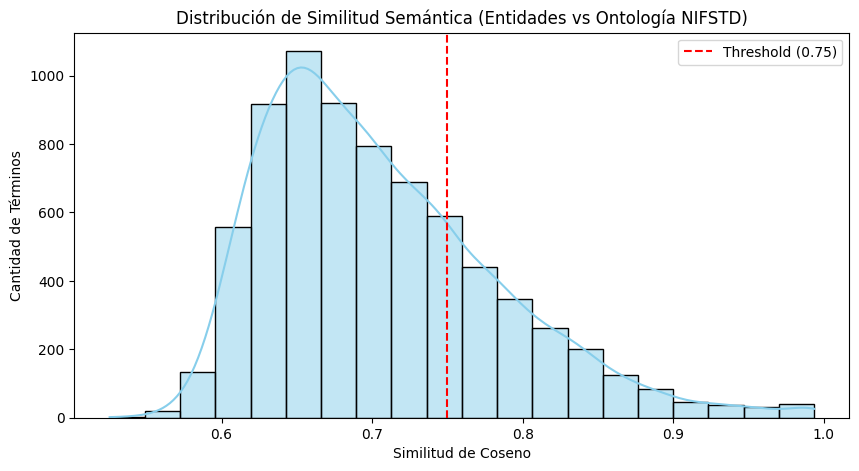


📊 RESUMEN:
Total de términos analizados: 7310
Términos Mapeados: 1836
Términos Residuales: 5474

Términos Residuales (Top 10):
['mas tenso', 'iz quierdo', 'elevacion de', 'ubicacion', 'hominivorax', 'apetito', 'sobrecarga', 'clínicas', 'aguda', 'mucopolisacarido']


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tabla de términos alineados vs residuales
print("Muestra de Alineamiento:")
# CAMBIO: Usamos df_results que es el nombre definido en la celda anterior
display(df_results.sort_values(by="similarity", ascending=False).head(10))

# 2. Gráfico de distribución de similitudes
plt.figure(figsize=(10, 5))
sns.histplot(df_results['similarity'], bins=20, kde=True, color='skyblue')
plt.axvline(ALIGNMENT_THRESHOLD, color='red', linestyle='--', label=f'Threshold ({ALIGNMENT_THRESHOLD})')
plt.title("Distribución de Similitud Semántica (Entidades vs Ontología NIFSTD)")
plt.xlabel("Similitud de Coseno")
plt.ylabel("Cantidad de Términos")
plt.legend()
plt.show()

# 3. Mostrar términos residuales
# CAMBIO: Usamos df_results aquí también
residuals = df_results[df_results['status'] == "Residual"]['term'].tolist()
print(f"\n📊 RESUMEN:")
print(f"Total de términos analizados: {len(df_results)}")
print(f"Términos Mapeados: {len(df_results) - len(residuals)}")
print(f"Términos Residuales: {len(residuals)}")

print(f"\nTérminos Residuales (Top 10):")
print(residuals[:10])